# MHIST Baseline

Train and evaluate a baseline model.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from PIL import Image

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.1+cpu
Torchvision version: 0.29.1+cpu
Device: cpu


In [2]:
# Load the train, validation, and test splits

train_df = pd.read_csv("../data/metadata/train_split.csv")
val_df = pd.read_csv("../data/metadata/val_split.csv")
test_df = pd.read_csv("../data/metadata/test_split.csv")

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTraining class distribution:")
print(train_df["Majority Vote Label"].value_counts())

print("\nValidation class distribution:")
print(val_df["Majority Vote Label"].value_counts())

print("\nTest class distribution:")
print(test_df["Majority Vote Label"].value_counts())

Training samples: 1740
Validation samples: 435
Test samples: 977

Training class distribution:
Majority Vote Label
HP     1236
SSA     504
Name: count, dtype: int64

Validation class distribution:
Majority Vote Label
HP     309
SSA    126
Name: count, dtype: int64

Test class distribution:
Majority Vote Label
HP     617
SSA    360
Name: count, dtype: int64


In [3]:
class MHISTDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # Convert class names to numerical labels
        self.label_map = {
            "HP": 0,
            "SSA": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_name = row["Image Name"]
        label_name = row["Majority Vote Label"]

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        label = self.label_map[label_name]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [4]:
# Image preprocessing for ResNet18

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [ ]:
# Resolve the MHIST image directory across common dataset layouts
image_candidates = [
    os.path.abspath("../data/raw/images"),
    os.path.abspath("../data/raw/images/images"),
    os.path.abspath("../data/images"),
]
image_dir = next((path for path in image_candidates if os.path.exists(path)), image_candidates[0])

if not os.path.exists(image_dir):
    raise FileNotFoundError(
        "MHIST image directory not found. Download or extract the dataset into one of: "
        + ", ".join(image_candidates)
    )

print("Using image directory:", image_dir)

# Create datasets
train_dataset = MHISTDataset(
    train_df,
    image_dir,
    transform=train_transform
)

val_dataset = MHISTDataset(
    val_df,
    image_dir,
    transform=val_test_transform
)

test_dataset = MHISTDataset(
    test_df,
    image_dir,
    transform=val_test_transform
)

print("Datasets created successfully!")
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset: 1740
Validation dataset: 435
Test dataset: 977


In [13]:
# Create DataLoaders

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully!
Training batches: 55
Validation batches: 14
Test batches: 31


In [14]:
# Test one batch from the training DataLoader

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Labels:", labels[:10])


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Labels: tensor([0, 0, 0, 0, 1, 1, 0, 0, 0, 1])


In [15]:
print("Current working directory:")
print(os.getcwd())

print("\nImage directory:")
print(image_dir)

print("\nFirst image name:")
print(train_df.iloc[0]["Image Name"])

first_image_path = os.path.join(
    image_dir,
    train_df.iloc[0]["Image Name"]
)

print("\nFull image path:")
print(first_image_path)

print("\nDoes this file exist?")
print(os.path.exists(first_image_path))

Current working directory:
c:\Users\hp\OneDrive\Desktop\MHIST-Research\Deep-learning-PBL-3\MHIST-Research\notebooks

Image directory:
../data/raw/images/images

First image name:
MHIST_edl.png

Full image path:
../data/raw/images/images\MHIST_edl.png

Does this file exist?
True


In [9]:
print("Current working directory:")
print(os.getcwd())

print("\nImage directory as absolute path:")
print(os.path.abspath(image_dir))

print("\nDoes image folder exist?")
print(os.path.exists(os.path.abspath(image_dir)))

print("\nDoes raw data folder exist?")
print(os.path.exists(os.path.abspath("../data/raw")))

Current working directory:
c:\Users\hp\OneDrive\Desktop\MHIST-Research\Deep-learning-PBL-3\MHIST-Research\notebooks

Image directory as absolute path:
c:\Users\hp\OneDrive\Desktop\MHIST-Research\Deep-learning-PBL-3\MHIST-Research\data\raw\images

Does image folder exist?
True

Does raw data folder exist?
True


In [10]:
image_folder = os.path.abspath(image_dir)

files = os.listdir(image_folder)

print("Number of files/folders:", len(files))
print("\nFirst 20 items:")
print(files[:20])

Number of files/folders: 1

First 20 items:
['images']


In [16]:
# Create ResNet18 baseline model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="DEFAULT")

# Replace the final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print("ResNet18 loaded successfully!")
print("Device:", device)
print("Output classes:", 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet18 loaded successfully!
Device: cpu
Output classes: 2


In [17]:
# Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 0.0001)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001


In [18]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully!")

Training function created successfully!


In [19]:
def validate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # No gradients needed during validation
    with torch.no_grad():

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Track loss
            running_loss += loss.item() * images.size(0)

            # Track accuracy
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function created successfully!")

Validation function created successfully!


In [66]:
# Train ResNet18 for 5 epochs

num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )
   


Epoch [1/5] Train Loss: 0.1283 | Train Acc: 0.9506 | Val Loss: 0.2650 | Val Acc: 0.8920
Epoch [2/5] Train Loss: 0.1194 | Train Acc: 0.9511 | Val Loss: 0.2755 | Val Acc: 0.8897
Epoch [3/5] Train Loss: 0.1350 | Train Acc: 0.9523 | Val Loss: 0.2845 | Val Acc: 0.8874
Epoch [4/5] Train Loss: 0.1455 | Train Acc: 0.9402 | Val Loss: 0.2653 | Val Acc: 0.8966
Epoch [5/5] Train Loss: 0.1424 | Train Acc: 0.9408 | Val Loss: 0.2635 | Val Acc: 0.8897


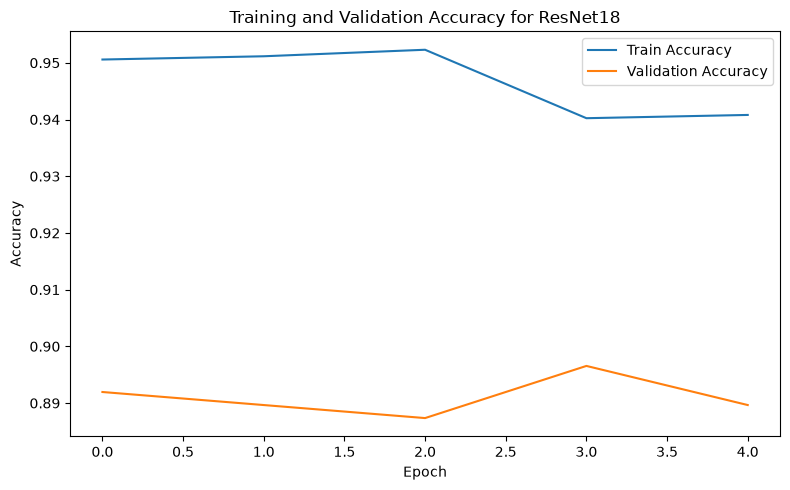

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
if "train_accuracies" in globals():
    plt.plot(train_accuracies, label="Train Accuracy")
else:
    print("Training history not found. Run the training cell first.")
if "val_accuracies" in globals():
    plt.plot(val_accuracies, label="Validation Accuracy")
else:
    print("Validation history not found. Run the training cell first.")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy for ResNet18")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
auc = roc_auc_score(all_labels, all_probabilities)

cm = confusion_matrix(all_labels, all_predictions)

print("ResNet18 Test Results")
print("---------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

ResNet18 Test Results
---------------------
Accuracy : 0.7922
Precision: 0.6612
Recall   : 0.8944
F1 Score : 0.7603
ROC-AUC  : 0.8949

Confusion Matrix:
[[452 165]
 [ 38 322]]


In [22]:
import torch
import torch.nn as nn
from torchvision import models

print("PyTorch:", torch.__version__)
print("EfficientNet-B0 setup started!")

PyTorch: 2.14.1+cpu
EfficientNet-B0 setup started!


In [23]:
# Load pretrained EfficientNet-B0

weights = models.EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=weights)

print("EfficientNet-B0 loaded successfully!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


EfficientNet-B0 loaded successfully!


In [24]:
# Replace the final classifier for our 2-class MHIST problem

num_features = efficientnet.classifier[1].in_features

efficientnet.classifier[1] = nn.Linear(num_features, 2)

print(efficientnet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [25]:
# Select the available device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

efficientnet = efficientnet.to(device)

print("Using device:", device)

Using device: cpu


In [26]:
# Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    efficientnet.parameters(),
    lr=0.0001
)

print("Loss function and optimizer are ready!")

Loss function and optimizer are ready!


In [27]:
# Check existing MHIST DataLoaders

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 55
Validation batches: 14
Test batches: 31


In [28]:
# Check one training batch

images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Labels in batch:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
Labels in batch: tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 1])


In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function is ready!")

Training function is ready!


In [30]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function is ready!")

Validation function is ready!


In [31]:
# Train EfficientNet-B0 for 5 epochs

num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        efficientnet,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        efficientnet,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/5] Train Loss: 0.5200 | Train Acc: 0.7471 | Val Loss: 0.3529 | Val Acc: 0.8368
Epoch [2/5] Train Loss: 0.3776 | Train Acc: 0.8310 | Val Loss: 0.2912 | Val Acc: 0.8736
Epoch [3/5] Train Loss: 0.3094 | Train Acc: 0.8672 | Val Loss: 0.2777 | Val Acc: 0.8851
Epoch [4/5] Train Loss: 0.2801 | Train Acc: 0.8856 | Val Loss: 0.2568 | Val Acc: 0.8828
Epoch [5/5] Train Loss: 0.2530 | Train Acc: 0.9000 | Val Loss: 0.2584 | Val Acc: 0.8874


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
if "train_accuracies" in globals():
    plt.plot(train_accuracies, label="Train Accuracy")
else:
    print("Training history not found. Run the training cell first.")
if "val_accuracies" in globals():
    plt.plot(val_accuracies, label="Validation Accuracy")
else:
    print("Validation history not found. Run the training cell first.")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

efficientnet.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet(images)

        # Predicted class
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # Probability of SSA (class 1)
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)

cm = confusion_matrix(all_labels, all_predictions)


print("EfficientNet-B0 Test Results")
print("----------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

EfficientNet-B0 Test Results
----------------------------
Accuracy : 0.8506
Precision: 0.7716
Recall   : 0.8444
F1 Score : 0.8064
ROC-AUC  : 0.9230

Confusion Matrix:
[[527  90]
 [ 56 304]]


In [33]:
# Save EfficientNet-B0 baseline results

efficientnet_results = {
    "Model": "EfficientNet-B0",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

print("EfficientNet-B0 results saved:")
print(efficientnet_results)

EfficientNet-B0 results saved:
{'Model': 'EfficientNet-B0', 'Accuracy': 0.8505629477993859, 'Precision': 0.7715736040609137, 'Recall': 0.8444444444444444, 'F1 Score': 0.8063660477453581, 'ROC-AUC': 0.9229830722132182}


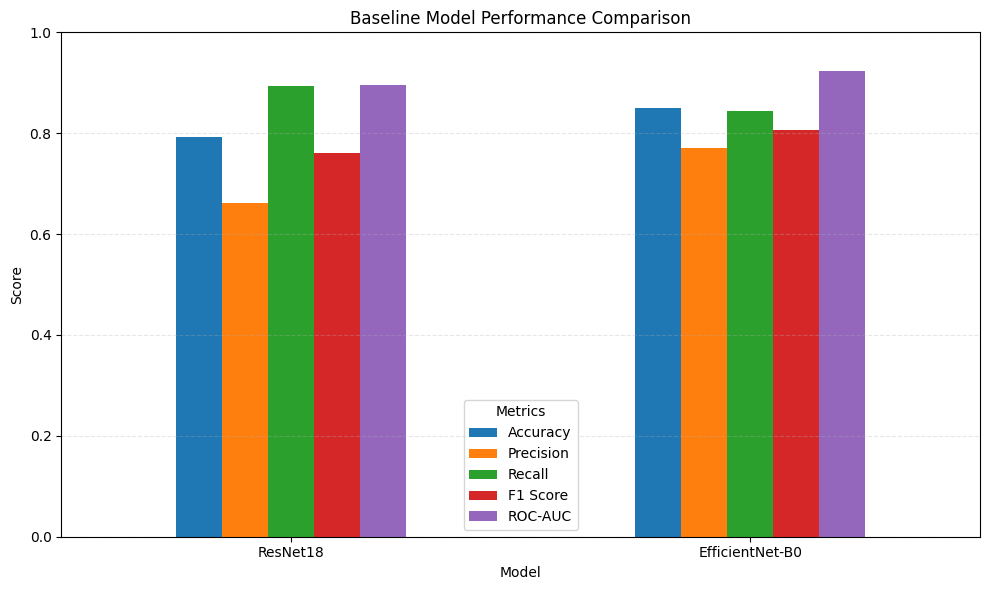

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Baseline model results
results = pd.DataFrame({
    "Model": ["ResNet18", "EfficientNet-B0"],
    "Accuracy": [0.7922, 0.8505629478],
    "Precision": [0.6612, 0.7715736041],
    "Recall": [0.8944, 0.8444444444],
    "F1 Score": [0.7603, 0.8063660477],
    "ROC-AUC": [0.8949, 0.9229830722]
})

# Set model names as index
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()